In [ ]:
!pip install datasets transformers faiss-cpu sentencepiece --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platf

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **Dataset**

In [ ]:
# STEP 1.2: Load HotpotQA dataset
from datasets import load_dataset

dataset = load_dataset("hotpot_qa", "fullwiki")
print(f"Train size: {len(dataset['train'])}")
print(f"Example keys: {dataset['train'][0].keys()}")

README.md:   0%|          | 0.00/9.19k [00:00<?, ?B/s]

hotpot_qa.py:   0%|          | 0.00/6.42k [00:00<?, ?B/s]

The repository for hotpot_qa contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/hotpot_qa.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7405 [00:00<?, ? examples/s]

Train size: 90447
Example keys: dict_keys(['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'])


In [ ]:
# Build a list of documents for retrieval (title + paragraphs)
import random

# Set the random seed for reproducibility
random.seed(42)

# Step 1: Sample entries from the HotpotQA train set
full_subset = dataset['train'].select(random.sample(range(len(dataset['train'])), 1000))

# Step 2: Split into training and testing
train_subset = full_subset.select(range(800))
test_subset = full_subset.select(range(800, 1000))

documents = []
questions = []

'''for sample in subset:
    titles = sample['context']['title']
    sentences = sample['context']['sentences']

    for title, para_list in zip(titles, sentences):
        for para in para_list:
            if len(para.strip()) > 20:
                documents.append({"title": title, "text": para})

    # Save question and supporting facts
    questions.append(sample)'''


# Build sentence-level documents from training samples
documents = []
#for sample in train_subset:
for sample in full_subset:
    titles = sample['context']['title']
    sentences = sample['context']['sentences']
    for title, sentence_list in zip(titles, sentences):
        for sentence in sentence_list:
            if len(sentence.strip()) > 20:
                documents.append({"title": title, "text": sentence})

    # Save question and supporting facts
    questions.append(sample)

print(f"Total candidate docs for retrieval: {len(documents)}")
print("Sample doc:", documents[0])


Total candidate docs for retrieval: 41103
Sample doc: {'title': 'Nathan Barksdale', 'text': 'Nathan Barksdale (1961 – February 13, 2016) was a Baltimore drug dealer dramatized in the HBO series The Wire, but the extent to which any of the show’s characters or plot lines are based on his life is disputed.'}


# **Initialize Encoder (must run everytime before new training)**

**Initialize DPR**

In [ ]:
from transformers import DPRQuestionEncoder, DPRQuestionEncoderTokenizer
from transformers import DPRContextEncoder, DPRContextEncoderTokenizer

# Load DPR encoders & tokenizers

q_encoder = DPRQuestionEncoder.from_pretrained("facebook/dpr-question_encoder-single-nq-base")
q_tokenizer = DPRQuestionEncoderTokenizer.from_pretrained("facebook/dpr-question_encoder-single-nq-base")

ctx_encoder = DPRContextEncoder.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")
ctx_tokenizer = DPRContextEncoderTokenizer.from_pretrained("facebook/dpr-ctx_encoder-single-nq-base")



Some weights of the model checkpoint at facebook/dpr-question_encoder-single-nq-base were not used when initializing DPRQuestionEncoder: ['question_encoder.bert_model.pooler.dense.bias', 'question_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRQuestionEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRQuestionEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at facebook/dpr-ctx_encoder-single-nq-base were not used when initializing DPRContextEncoder: ['ctx_encoder.bert_model.pooler.dense.bias', 'ctx_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRContextEncoder from the

**Initialize Contriever (ignore contriever for now)**

In [ ]:
from transformers import AutoTokenizer, AutoModel

# Load Contriever
contriever_tokenizer = AutoTokenizer.from_pretrained("facebook/contriever")
contriever_encoder = AutoModel.from_pretrained("facebook/contriever").to(device)

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

# **Encode & FAISS functions**

In [ ]:
'''def encode_documents(documents):
    ctx_texts = [doc["text"] for doc in documents]
    inputs = ctx_tokenizer(ctx_texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
    with torch.no_grad():
        embeddings = ctx_encoder(**inputs).pooler_output
    #return embeddings.numpy()
    return embeddings.detach().cpu().numpy().copy()  # Add .copy() to make it C-contiguous'''

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
q_encoder.to(device)
ctx_encoder.to(device)

from tqdm import tqdm


def encode_documents_dpr(documents, ctx_encoder, ctx_tokenizer, device, batch_size=32, show_progress=True):
    ctx_encoder.eval()
    ctx_encoder.to(device)

    all_embeddings = []
    loop = range(0, len(documents), batch_size)
    if show_progress:
        loop = tqdm(loop, desc="Encoding documents")

    for i in loop:
        batch_docs = documents[i:i + batch_size]
        texts = [doc["text"] for doc in batch_docs]
        inputs = ctx_tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            embeddings = ctx_encoder(**inputs).pooler_output
            all_embeddings.append(embeddings.detach().cpu().numpy())

    return np.concatenate(all_embeddings, axis=0)

def encode_query_DPR(question):
    inputs = q_tokenizer(
        question,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512   # Set a clear max_length
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}  # Move each tensor to correct device

    q_encoder.to(device)  # Ensure model is on the right device too

    with torch.no_grad():
        outputs = q_encoder(**inputs)
        embedding = outputs.pooler_output

    return embedding.detach().cpu().numpy()


# def encode_query_DPR(question, retrieved_doc_embs=None):
#     inputs = q_tokenizer(question, return_tensors="pt", truncation=True, padding=True)
#     inputs = {k: v.to(device) for k, v in inputs.items()}
#     with torch.no_grad():
#         embedding = q_encoder(**inputs).pooler_output

#     if retrieved_doc_embs is not None:
#         embedding = reformulator(embedding, retrieved_doc_embs)
#     else:
#         # If no doc provided, just pass original query
#         embedding = embedding

#     return embedding.detach().cpu().numpy()


def encode_passages_contriever(passages, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(passages), batch_size), desc="Encoding passages with Contriever"):
        batch = passages[i:i+batch_size]
        inputs = contriever_tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = contriever_encoder(**inputs)
            embeddings = outputs.last_hidden_state[:, 0]  # CLS token
            #embeddings = outputs.pooler_output
        all_embeddings.append(embeddings.cpu().numpy())
    return np.concatenate(all_embeddings, axis=0)

def encode_query_contriever(question):
    return encode_passages_contriever([question])[0].reshape(1, -1)


import faiss
import numpy as np

def build_faiss_index(doc_embeddings):
    dim = doc_embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)  # Inner product (dot product for cosine similarity)
    faiss.normalize_L2(doc_embeddings)
    #index.add(np.ascontiguousarray(doc_embeddings))  # Ensure C-contiguous
    index.add(doc_embeddings)
    return index


import numpy as np
import datetime
import os

def save_embeddings_to_drive(doc_embeddings, tag, folder_path="/content/drive/MyDrive/IST558"):
    # Create timestamped filename
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    #filename = f"doc_embeddings_DPR_{tag}_{timestamp}.npy"
    filename = f"doc_embeddings_DPR_{tag}.npy"

    # Ensure the folder exists
    os.makedirs(folder_path, exist_ok=True)

    # Full path to save
    full_path = os.path.join(folder_path, filename)

    # Save the embeddings
    np.save(full_path, doc_embeddings)
    print(f"Saved embeddings to: {full_path}")


# **Can skip to Training DPR**

## **Encode documents**

**DPR**

In [ ]:
# Encode document corpus (can take some time)
doc_embeddings = encode_documents_dpr(documents, ctx_encoder, ctx_tokenizer, show_progress=True, device=device)

Encoding documents: 100%|██████████| 1285/1285 [02:59<00:00,  7.15it/s]


**Contriever**

In [ ]:
# Encode document corpus (can take some time)
doc_embeddings = encode_passages_contriever([doc["text"] for doc in documents])

## **Save/Load initial embeddings**

**Rename the tag for different file name**

In [ ]:
# save embeddings
save_embeddings_to_drive(doc_embeddings, tag="hotpot_800_post_2rounds")

Saved embeddings to: /content/drive/MyDrive/IST558/doc_embeddings_DPR_hotpot_800_post_2rounds_20250427_211113.npy


**Load embeddings**

In [ ]:
import numpy as np
import os

# Load later
# /content/drive/MyDrive/IST558/doc_embeddings_hotpot_DPR__hotpot_800_init_20250427_174412.npy
doc_embeddings = np.load("/content/drive/MyDrive/IST558/doc_embeddings_hotpot_3000_DPR__20250427_013816.npy")

## **Build FAISS**

In [ ]:
import random
import numpy as np

# Assuming 'dataset' is already loaded and contains the 'train' split
random_index = random.randint(0, len(dataset['train']) - 1)
question = dataset['train'][random_index]['question']

# Build FAISS index
faiss_index = build_faiss_index(doc_embeddings)

# Encode the question
query_embedding = encode_query_DPR(question)
#query_embedding = encode_query_contriever(question)
original_query_embedding = torch.tensor(query_embedding, device=device)


# **Iterative Training DPR**

## **Generate data**

In [ ]:
from tqdm import tqdm


def generate_dpr_training_data(dataset, documents, max_samples,
                                negatives_per_sample=2, hard_negatives_per_sample=2,
                                q_encoder=None, q_tokenizer=None, faiss_index=None,
                                use_hard_neg=False):
    training_data = []

    dataset = dataset.shuffle(seed=random.randint(0, 10000))

    # === Add tqdm progress bar ===
    loop = tqdm(dataset.select(range(max_samples)), desc="Generating DPR samples")

    for sample in loop:
        question = sample['question']
        pos_titles = sample['supporting_facts']['title']
        pos_sent_ids = sample['supporting_facts']['sent_id']

        # Build title→sentence map
        title_to_sentences = {
            t: s for t, s in zip(sample['context']['title'], sample['context']['sentences'])
        }

        # Get positive contexts
        positive_ctxs = []
        for title, sent_id in zip(pos_titles, pos_sent_ids):
            if title in title_to_sentences and sent_id < len(title_to_sentences[title]):
                positive_ctxs.append({
                    "title": title,
                    "text": title_to_sentences[title][sent_id]
                })

        if len(positive_ctxs) == 0:
            continue

        # Random easy negatives
        neg_candidates = [doc for doc in documents if doc["title"]not in pos_titles]
        easy_negs = random.sample(neg_candidates, min(negatives_per_sample, len(neg_candidates)))
        easy_negative_ctxs = [{"title": doc["title"], "text": doc["text"]} for doc in easy_negs]

        # Hard negatives
        hard_negative_ctxs = []
        if use_hard_neg and q_encoder is not None and q_tokenizer is not None and faiss_index is not None:
            hard_negative_ctxs = get_hard_negatives(
                question, pos_titles, documents, q_encoder, q_tokenizer, faiss_index,
                top_k=hard_negatives_per_sample
            )

        # Combine easy + hard negatives
        negative_ctxs = easy_negative_ctxs + hard_negative_ctxs

        training_data.append({
            "question": question,
            "positive_ctxs": positive_ctxs,
            "negative_ctxs": negative_ctxs
        })

    return training_data




def get_hard_negatives(question, pos_titles, documents, q_encoder, q_tokenizer, faiss_index, top_k=5):
    """
    Retrieve hard negatives for a question using FAISS search.
    """
    # Encode question
    inputs = q_tokenizer(question, return_tensors="pt", truncation=True).to(q_encoder.device)

    with torch.no_grad():
        q_emb = q_encoder(**inputs).pooler_output.detach().cpu().numpy()

    faiss.normalize_L2(q_emb)

    # Search top-k
    D, I = faiss_index.search(q_emb, top_k)

    hard_negs = []
    seen_titles = set()

    for idx in I[0]:
        doc = documents[idx]
        title = doc["title"]

        # Make sure it's NOT a positive document
        if title not in pos_titles and title not in seen_titles:
            hard_negs.append({
                "title": title,
                "text": doc["text"]
            })
            seen_titles.add(title)

    return hard_negs



In [ ]:
import os
import json
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

# Optional: reduce fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

class DPRTripletDataset(Dataset):
    def __init__(self, jsonl_path):
        with open(jsonl_path, 'r') as f:
            self.samples = [json.loads(line.strip()) for line in f]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        return item["question"], item["positive_ctxs"][0]["text"], item["negative_ctxs"][0]["text"]


def collate_fn(batch, tokenizer_q, tokenizer_c, max_length=256):
    questions, positives, negatives = zip(*batch)
    q_inputs = tokenizer_q(list(questions), return_tensors="pt", padding=True, truncation=True, max_length=max_length)
    pos_inputs = tokenizer_c(list(positives), return_tensors="pt", padding=True, truncation=True, max_length=max_length)
    neg_inputs = tokenizer_c(list(negatives), return_tensors="pt", padding=True, truncation=True, max_length=max_length)
    return q_inputs, pos_inputs, neg_inputs


In [ ]:
## Data Hyperparams
max_samples_per_round = 800         # How many samples to generate each round
negatives_per_sample = 2            # Easy negatives per sample
#hard_negatives_per_sample = 2       # Hard negatives per sample

In [ ]:
import datetime
import os
import json

def save_training_data(training_data, tag="train", folder_path="./dpr_training_data"):

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"dpr_training_data_{tag}.jsonl"

    os.makedirs(folder_path, exist_ok=True)
    full_path = os.path.join(folder_path, filename)

    with open(full_path, "w") as f:
        for item in training_data:
            f.write(json.dumps(item) + "\n")

    print(f"Saved training data to: {full_path}")
    return full_path

print("Generating training data...")
dpr_data = generate_dpr_training_data(
    train_subset, documents,
    max_samples=max_samples_per_round,
    negatives_per_sample=negatives_per_sample,
    q_encoder=None, q_tokenizer=None, faiss_index=None,  # No need to pass if not using hard neg
    use_hard_neg=False
)

dataset_load_path = save_training_data(
    training_data=dpr_data,
    tag="train",  # or any tag you like
    folder_path="./dpr_training_data"
)

Generating training data...


Generating DPR samples: 100%|██████████| 800/800 [00:03<00:00, 237.68it/s]

Saved training data to: ./dpr_training_data/dpr_training_data_train.jsonl


## **Training function**

In [ ]:
def train_dpr(dpr_q_encoder, dpr_ctx_encoder, tokenizer_q, tokenizer_c, jsonl_path,
              device, epochs=1, lr=1e-5, batch_size=8, log_every=20, use_amp=True):

    dataset = DPRTripletDataset(jsonl_path)
    data_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda x: collate_fn(x, tokenizer_q, tokenizer_c)
    )

    optimizer = torch.optim.AdamW(list(dpr_q_encoder.parameters()) + list(dpr_ctx_encoder.parameters()), lr=lr)
    scaler = GradScaler() if use_amp else None

    dpr_q_encoder.train().to(device)
    dpr_ctx_encoder.train().to(device)

    for epoch in range(epochs):
        total_loss = 0
        batch_losses = []

        for step, batch in enumerate(data_loader):
            q_inputs, pos_inputs, neg_inputs = batch
            q_inputs = {k: v.to(device) for k, v in q_inputs.items()}
            pos_inputs = {k: v.to(device) for k, v in pos_inputs.items()}
            neg_inputs = {k: v.to(device) for k, v in neg_inputs.items()}

            optimizer.zero_grad()

            if use_amp:
                with autocast():
                    q_emb = dpr_q_encoder(**q_inputs).pooler_output
                    pos_emb = dpr_ctx_encoder(**pos_inputs).pooler_output
                    neg_emb = dpr_ctx_encoder(**neg_inputs).pooler_output

                    pos_sim = F.cosine_similarity(q_emb, pos_emb)
                    neg_sim = F.cosine_similarity(q_emb, neg_emb)
                    loss = F.margin_ranking_loss(pos_sim, neg_sim, torch.ones_like(pos_sim), margin=0.2)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            else:
                q_emb = dpr_q_encoder(**q_inputs).pooler_output
                pos_emb = dpr_ctx_encoder(**pos_inputs).pooler_output
                neg_emb = dpr_ctx_encoder(**neg_inputs).pooler_output

                pos_sim = F.cosine_similarity(q_emb, pos_emb)
                neg_sim = F.cosine_similarity(q_emb, neg_emb)
                loss = F.margin_ranking_loss(pos_sim, neg_sim, torch.ones_like(pos_sim), margin=0.2)

                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            batch_losses.append(loss.item())

            if (step + 1) % log_every == 0 or (step + 1) == len(data_loader):
                avg_recent = sum(batch_losses[-log_every:]) / min(log_every, len(batch_losses))
                print(f"[Epoch {epoch+1} | Step {step+1}/{len(data_loader)}] Avg Loss: {avg_recent:.4f}")

        print(f"Epoch {epoch+1} completed. Total Loss: {total_loss:.4f}")



In [ ]:
def iterative_train(documents, dataset, q_encoder, ctx_encoder, q_tokenizer, ctx_tokenizer,
                    device, num_rounds=5, max_samples=800, negatives_per_sample=2, hard_negatives_per_sample=2,
                    batch_size=32, lr=1e-5, epochs=2, use_amp=True, use_hard_neg=False,
                    model_checkpoint_dir="./checkpoints", dataset_save_path="./dpr_training_data.json", dataset_load_path=None, emb_dir=None):

    for round_idx in range(1, num_rounds + 1):
        print(f"\n=== Starting Iteration {round_idx}/{num_rounds} ===\n")

        # Step 1: Encode documents
        print("Encoding documents...")
        doc_embeddings = encode_documents_dpr(documents, ctx_encoder, ctx_tokenizer, device=device, show_progress=True)

        # Save embeddings for this iteration
        embedding_path = save_embeddings_to_drive(
            doc_embeddings=doc_embeddings,
            tag=f"iter{round_idx}",
            folder_path= emb_dir
        )

        # Step 2: Build FAISS index
        print("Building FAISS index...")
        faiss_index = build_faiss_index(doc_embeddings)

        # Step 3: Generate new training data (can skip without hard_neg)
        # print("Generating training data...")
        # dpr_data = generate_dpr_training_data(
        #     dataset, documents, max_samples=max_samples,
        #     negatives_per_sample=negatives_per_sample,
        #     q_encoder=q_encoder, q_tokenizer=q_tokenizer, faiss_index=faiss_index,
        #     use_hard_neg=use_hard_neg
        # )

        # # Save training data
        # dataset_path = save_training_data_to_drive(
        #     training_data=dpr_data,
        #     iteration=round_idx,
        #     tag="iterative",
        #     folder_path="./dpr_training_data"
        # )


        # Step 4: Train encoders on the new dataset
        print("Training encoders...")
        train_dpr(
            dpr_q_encoder=q_encoder,
            dpr_ctx_encoder=ctx_encoder,
            tokenizer_q=q_tokenizer,
            tokenizer_c=ctx_tokenizer,
            jsonl_path=dataset_load_path,
            device=device,
            epochs=epochs,
            lr=lr,
            batch_size=batch_size,
            log_every=10,
            use_amp=use_amp
        )

       # Step 5: Save updated encoders
        print("Saving checkpoint...")
        os.makedirs(model_checkpoint_dir, exist_ok=True)

        q_encoder_save_path = os.path.join(model_checkpoint_dir, f"q_encoder_iter{round_idx}")
        ctx_encoder_save_path = os.path.join(model_checkpoint_dir, f"ctx_encoder_iter{round_idx}")

        q_encoder.save_pretrained(q_encoder_save_path)
        ctx_encoder.save_pretrained(ctx_encoder_save_path)

        print(f"Saved q_encoder to {q_encoder_save_path}")
        print(f"Saved ctx_encoder to {ctx_encoder_save_path}")

        print(f"=== Iteration {round_idx} complete ===\n")


## **Iterative Training**

In [ ]:
# === Hyperparameters for Iterative DPR Training ===

## Training
epochs_per_round = 3                # How many epochs per training round
train_batch_size = 32               # Training batch size
learning_rate = 1e-5                # AdamW learning rate

## Iterations
num_rounds = 5                      # How many total rounds (encode → retrain → save → repeat)

## Save/load
model_checkpoint_dir = "/content/drive/MyDrive/IST558/checkpoints"  # Save models to Drive
dataset_save_path = "/content/drive/MyDrive/IST558/dpr_training_data.json"
emb_dir = "/content/drive/MyDrive/IST558/dpr_embeddings"
#model_checkpoint_dir = "./checkpoints"  # Save models to default Colab space
#dataset_save_path = "./dpr_training_data.json"

## Other
use_amp = True                      # Use mixed precision training
use_hard_neg = False                # Whether to mine hard negatives (so far hard neg will degrade performance)


In [ ]:
# === Start the full iterative training ===

iterative_train(
    documents=documents,
    dataset=train_subset,
    q_encoder=q_encoder,
    ctx_encoder=ctx_encoder,
    q_tokenizer=q_tokenizer,
    ctx_tokenizer=ctx_tokenizer,
    device=device,
    num_rounds=num_rounds,
    max_samples=max_samples_per_round,
    negatives_per_sample=negatives_per_sample,
    batch_size=train_batch_size,
    lr=learning_rate,
    epochs=epochs_per_round,
    use_amp=use_amp,
    model_checkpoint_dir=model_checkpoint_dir,
    dataset_save_path=dataset_save_path,
    dataset_load_path=dataset_load_path,
    emb_dir = emb_dir,
)



=== Starting Iteration 1/5 ===

Encoding documents...


Encoding documents: 100%|██████████| 1285/1285 [02:53<00:00,  7.40it/s]


Saved embeddings to: /content/drive/MyDrive/IST558/dpr_embeddings/doc_embeddings_DPR_iter1.npy
Building FAISS index...
Training encoders...


<ipython-input-161-65101780748a>:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
<ipython-input-161-65101780748a>:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[Epoch 1 | Step 10/25] Avg Loss: 0.0307
[Epoch 1 | Step 20/25] Avg Loss: 0.0194
[Epoch 1 | Step 25/25] Avg Loss: 0.0175
Epoch 1 completed. Total Loss: 0.5857
[Epoch 2 | Step 10/25] Avg Loss: 0.0049
[Epoch 2 | Step 20/25] Avg Loss: 0.0042
[Epoch 2 | Step 25/25] Avg Loss: 0.0043
Epoch 2 completed. Total Loss: 0.1124
[Epoch 3 | Step 10/25] Avg Loss: 0.0010
[Epoch 3 | Step 20/25] Avg Loss: 0.0005
[Epoch 3 | Step 25/25] Avg Loss: 0.0005
Epoch 3 completed. Total Loss: 0.0177
Saving checkpoint...
Saved q_encoder to /content/drive/MyDrive/IST558/checkpoints/q_encoder_iter1
Saved ctx_encoder to /content/drive/MyDrive/IST558/checkpoints/ctx_encoder_iter1
=== Iteration 1 complete ===


=== Starting Iteration 2/5 ===

Encoding documents...


...

Saved embeddings to: /content/drive/MyDrive/IST558/dpr_embeddings/doc_embeddings_DPR_iter3.npy
Building FAISS index...
Training encoders...
[Epoch 1 | Step 10/25] Avg Loss: 0.0002
[Epoch 1 | Step 20/25] Avg Loss: 0.0000
[Epoch 1 | Step 25/25] Avg Loss: 0.0001
Epoch 1 completed. Total Loss: 0.0025
[Epoch 2 | Step 10/25] Avg Loss: 0.0001
[Epoch 2 | Step 20/25] Avg Loss: 0.0000
[Epoch 2 | Step 25/25] Avg Loss: 0.0001
Epoch 2 completed. Total Loss: 0.0024
[Epoch 3 | Step 10/25] Avg Loss: 0.0004
[Epoch 3 | Step 20/25] Avg Loss: 0.0001
[Epoch 3 | Step 25/25] Avg Loss: 0.0001
Epoch 3 completed. Total Loss: 0.0055
Saving checkpoint...
Saved q_encoder to /content/drive/MyDrive/IST558/checkpoints/q_encoder_iter3
Saved ctx_encoder to /content/drive/MyDrive/IST558/checkpoints/ctx_encoder_iter3
=== Iteration 3 complete ===


=== Starting Iteration 4/5 ===

Encoding documents...


Encoding documents: 100%|██████████| 1285/1285 [02:53<00:00,  7.40it/s]


Saved embeddings to: /content/drive/MyDrive/IST558/dpr_embeddings/doc_embeddings_DPR_iter4.npy
Building FAISS index...
Training encoders...
[Epoch 1 | Step 10/25] Avg Loss: 0.0000
[Epoch 1 | Step 20/25] Avg Loss: 0.0001
[Epoch 1 | Step 25/25] Avg Loss: 0.0000
Epoch 1 completed. Total Loss: 0.0007
[Epoch 2 | Step 10/25] Avg Loss: 0.0002
[Epoch 2 | Step 20/25] Avg Loss: 0.0001
[Epoch 2 | Step 25/25] Avg Loss: 0.0001
Epoch 2 completed. Total Loss: 0.0021
[Epoch 3 | Step 10/25] Avg Loss: 0.0001
[Epoch 3 | Step 20/25] Avg Loss: 0.0000
[Epoch 3 | Step 25/25] Avg Loss: 0.0000
Epoch 3 completed. Total Loss: 0.0007
Saving checkpoint...
Saved q_encoder to /content/drive/MyDrive/IST558/checkpoints/q_encoder_iter4
Saved ctx_encoder to /content/drive/MyDrive/IST558/checkpoints/ctx_encoder_iter4
=== Iteration 4 complete ===


=== Starting Iteration 5/5 ===

Encoding documents...


Encoding documents: 100%|██████████| 1285/1285 [02:53<00:00,  7.40it/s]


Saved embeddings to: /content/drive/MyDrive/IST558/dpr_embeddings/doc_embeddings_DPR_iter5.npy
Building FAISS index...
Training encoders...
[Epoch 1 | Step 10/25] Avg Loss: 0.0002
[Epoch 1 | Step 20/25] Avg Loss: 0.0002
[Epoch 1 | Step 25/25] Avg Loss: 0.0002
Epoch 1 completed. Total Loss: 0.0033
[Epoch 2 | Step 10/25] Avg Loss: 0.0000
[Epoch 2 | Step 20/25] Avg Loss: 0.0000
[Epoch 2 | Step 25/25] Avg Loss: 0.0000
Epoch 2 completed. Total Loss: 0.0000
[Epoch 3 | Step 10/25] Avg Loss: 0.0001
[Epoch 3 | Step 20/25] Avg Loss: 0.0002
[Epoch 3 | Step 25/25] Avg Loss: 0.0002
Epoch 3 completed. Total Loss: 0.0031
Saving checkpoint...
Saved q_encoder to /content/drive/MyDrive/IST558/checkpoints/q_encoder_iter5
Saved ctx_encoder to /content/drive/MyDrive/IST558/checkpoints/ctx_encoder_iter5
=== Iteration 5 complete ===



## **Data evaluation**

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

def evaluate_training_data(training_data, q_encoder, q_tokenizer, ctx_encoder, ctx_tokenizer, device="cuda", max_samples=1000):
    """
    Evaluate the quality of generated DPR training data with a progress bar.

    Args:
        training_data: List of dicts with "question", "positive_ctxs", "negative_ctxs"
        q_encoder: Query encoder model
        q_tokenizer: Tokenizer for queries
        ctx_encoder: Context encoder model
        ctx_tokenizer: Tokenizer for documents
        device: Device ("cuda" or "cpu")
        max_samples: Max samples to check
    """
    q_encoder.eval()
    ctx_encoder.eval()

    pos_sims = []
    neg_sims = []

    # Select a subset if too large
    subset = training_data if len(training_data) <= max_samples else training_data[:max_samples]

    # Add tqdm loop
    for sample in tqdm(subset, desc="Evaluating training samples"):
        question = sample["question"]
        positives = sample["positive_ctxs"]
        negatives = sample["negative_ctxs"]

        # Encode question
        q_inputs = q_tokenizer(question, return_tensors="pt", truncation=True, padding=True, max_length=256)
        q_inputs = {k: v.to(device) for k, v in q_inputs.items()}
        with torch.no_grad():
            q_emb = q_encoder(**q_inputs).pooler_output

        # Positive similarities
        for pos in positives:
            pos_inputs = ctx_tokenizer(pos["text"], return_tensors="pt", truncation=True, padding=True, max_length=256)
            pos_inputs = {k: v.to(device) for k, v in pos_inputs.items()}
            with torch.no_grad():
                pos_emb = ctx_encoder(**pos_inputs).pooler_output
            sim = F.cosine_similarity(q_emb, pos_emb).item()
            pos_sims.append(sim)

        # Negative similarities
        for neg in negatives:
            neg_inputs = ctx_tokenizer(neg["text"], return_tensors="pt", truncation=True, padding=True, max_length=256)
            neg_inputs = {k: v.to(device) for k, v in neg_inputs.items()}
            with torch.no_grad():
                neg_emb = ctx_encoder(**neg_inputs).pooler_output
            sim = F.cosine_similarity(q_emb, neg_emb).item()
            neg_sims.append(sim)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.hist(pos_sims, bins=50, alpha=0.7, label="Positives")
    plt.hist(neg_sims, bins=50, alpha=0.7, label="Negatives")

    plt.xlabel("Cosine Similarity", fontsize=16)
    plt.ylabel("Frequency", fontsize=16)
    plt.title("Similarity Distribution: Positives vs Negatives", fontsize=18)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.show()

    # Quick statistics
    print(f"\nPositive similarities: mean={sum(pos_sims)/len(pos_sims):.3f}")
    print(f"Negative similarities: mean={sum(neg_sims)/len(neg_sims):.3f}")
    print(f"Gap: {sum(pos_sims)/len(pos_sims)-sum(neg_sims)/len(neg_sims):.3f}")


**Load encoders if needed**

In [ ]:
from transformers import DPRQuestionEncoder, DPRContextEncoder

def load_encoders_for_iteration(model_checkpoint_dir, iteration, device):
    """
    Load the saved q_encoder and ctx_encoder for a given iteration.
    """
    q_encoder_path = os.path.join(model_checkpoint_dir, f"q_encoder_iter{iteration}")
    ctx_encoder_path = os.path.join(model_checkpoint_dir, f"ctx_encoder_iter{iteration}")

    q_encoder = DPRQuestionEncoder.from_pretrained(q_encoder_path, local_files_only=True).to(device)
    ctx_encoder = DPRContextEncoder.from_pretrained(ctx_encoder_path, local_files_only=True).to(device)

    q_encoder.eval()
    ctx_encoder.eval()

    return q_encoder, ctx_encoder

# Load encoders saved after each iteration
q_encoder, ctx_encoder = load_encoders_for_iteration(
   # model_checkpoint_dir="./checkpoints",
   model_checkpoint_dir="/content/drive/MyDrive/IST558/checkpoints",
    iteration=3,  #******** Adjust this to see other iteration
    device=device
)

Evaluating training samples: 100%|██████████| 500/500 [00:26<00:00, 18.90it/s]


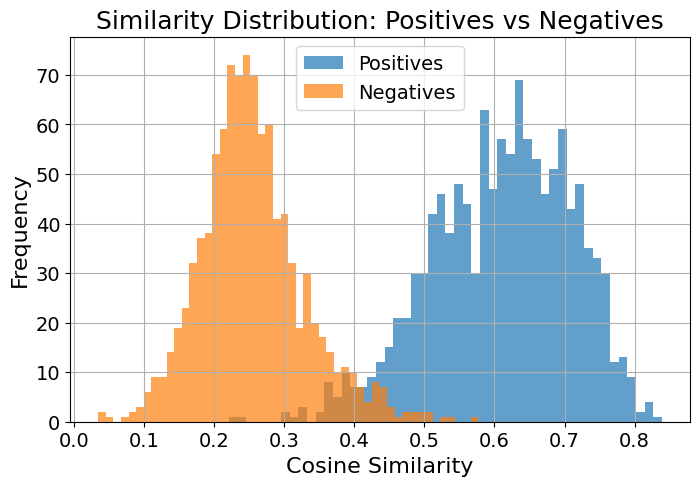


Positive similarities: mean=0.610
Negative similarities: mean=0.255
Gap: 0.355


In [ ]:
import json

def load_training_data(jsonl_path):
    with open(jsonl_path, "r") as f:
        return [json.loads(line.strip()) for line in f]

training_data = load_training_data("./dpr_training_data/dpr_training_data_train.jsonl") # Adjust to the directory of saved data

q_encoder.to(device)
ctx_encoder.to(device)

evaluate_training_data(
    training_data=training_data,
    q_encoder=q_encoder,
    q_tokenizer=q_tokenizer,
    ctx_encoder=ctx_encoder,
    ctx_tokenizer=ctx_tokenizer,
    device=device,
    max_samples=500
)

# **Load / Re-encode with the trained encoder and rebuild-FAISS**

**Load encoder (can skip)**

In [ ]:
# Load encoders saved after each iteration
q_encoder, ctx_encoder = load_encoders_for_iteration(
   # model_checkpoint_dir="./checkpoints",
   model_checkpoint_dir="/content/drive/MyDrive/IST558/checkpoints",
    iteration=3, # Or any iteration
    device=device
)

**Load Embeddings and rebuild FAISS(can skip)**

In [ ]:
def load_embeddings_for_iteration(folder_path, iteration):
    file_path = os.path.join(folder_path, f"doc_embeddings_DPR_iter{iteration}.npy")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Embedding file not found at: {file_path}")

    embeddings = np.load(file_path)
    return embeddings

doc_embeddings = load_embeddings_for_iteration(
    #folder_path="./dpr_embeddings/", # or emb_dir
    folder_path= emb_dir, # or emb_dir
    iteration=4  # Or any iteration (remember to use "encoder iter" + 1
                 # as the embeddings are generated one iter after the encoder is trained
                  # Will need to re-encode if want to use the newest encoder)
)

# Normalize and build FAISS index
faiss_index = faiss.IndexFlatIP(doc_embeddings.shape[1])
faiss.normalize_L2(doc_embeddings)
faiss_index.add(doc_embeddings)
faiss.write_index(faiss_index, "faiss_finetuned.index")

print("Re-encoding + FAISS index complete")

save_embeddings_to_drive(doc_embeddings, tag="finetuned")

Re-encoding + FAISS index complete
Saved embeddings to: /content/drive/MyDrive/IST558/doc_embeddings_DPR_finetuned.npy


**Re-encode and rebuild FAISS (Must run after training or loading another encoder, unless loaded embeddings)**

In [ ]:
import numpy as np
import faiss
from tqdm import tqdm


# Encode all documents again with the updated encoder
doc_embeddings = encode_documents_dpr(documents, ctx_encoder, ctx_tokenizer, device)

# Save embeddings to file
np.save("doc_embeddings_finetuned.npy", doc_embeddings)

# Normalize and build FAISS index
faiss_index = faiss.IndexFlatIP(doc_embeddings.shape[1])
faiss.normalize_L2(doc_embeddings)
faiss_index.add(doc_embeddings)
faiss.write_index(faiss_index, "faiss_finetuned.index")

print("Re-encoding + FAISS index complete")

save_embeddings_to_drive(doc_embeddings, tag="finetuned")

Encoding documents: 100%|██████████| 1272/1272 [02:52<00:00,  7.39it/s]


Re-encoding + FAISS index complete
Saved embeddings to: /content/drive/MyDrive/IST558/doc_embeddings_DPR_finetuned.npy


# **Attention Weighted Refinement logic (no training needed)**

In [ ]:
def refined_embedding(Q_s, retrieved_embs, confidence_scores, tau=0.6, alpha=0.7):
    Q_s = Q_s.squeeze(0)
    if not isinstance(Q_s, torch.Tensor):
        Q_s = torch.tensor(Q_s, device=retrieved_embs[0].device)

    R_filtered = [R for R, score in zip(retrieved_embs, confidence_scores) if score >= tau]
    if not R_filtered:
        return Q_s.unsqueeze(0)

    R_filtered = [R.clone().detach().to(Q_s.device) if isinstance(R, torch.Tensor) else torch.tensor(R, device=Q_s.device) for R in R_filtered]
    R_filtered = torch.stack(R_filtered)

    # Simple attention
    attention_weights = torch.nn.functional.softmax(torch.matmul(R_filtered, Q_s), dim=0)
    R_weighted = torch.sum(attention_weights.unsqueeze(1) * R_filtered, dim=0)

    # === simple MLP transformation ===
    ff = nn.Sequential(
        nn.Linear(Q_s.size(0), Q_s.size(0)),
        nn.ReLU(),
        nn.Linear(Q_s.size(0), Q_s.size(0))
    ).to(Q_s.device)
    R_weighted_transformed = ff(R_weighted)

    # Blend
    Q_next = alpha * Q_s + (1 - alpha) * R_weighted_transformed

    return Q_next.unsqueeze(0)


# **Retrieval logic**

In [ ]:
import torch.nn as nn

def retrieve_top_k(index, query_embedding, documents, k=3, exclude_indices=set()):
    # Normalize the query for cosine similarity (only needed for IndexFlatIP)
    faiss.normalize_L2(query_embedding)

    # Retrieve more than needed in case some are excluded
    D, I = index.search(query_embedding, k + len(exclude_indices))

    results = []
    final_indices = []
    final_scores = []

    seen_indices = set()
    seen_texts = set()

    for score, idx in zip(D[0], I[0]):
        doc = documents[idx]
        if idx not in exclude_indices and idx not in seen_indices and doc["text"] not in seen_texts:
            results.append(doc)
            final_indices.append(idx)
            final_scores.append(score)
            seen_indices.add(idx)
            seen_texts.add(doc["text"])

        if len(results) == k:
            break

    return results, final_indices, final_scores

def multi_hop_retrieve(question, q_encoder, q_tokenizer, device, num_hops=2, k=3, confidence_threshold=0.6, verbose=True, refiner=None, alpha=None):
    q_encoder = q_encoder.to(device)
    query_embedding = encode_query_DPR(question)
    #query_embedding = encode_query_contriever(question)
    original_query_embedding = torch.tensor(query_embedding).to("cuda" if torch.cuda.is_available() else "cpu")
    exclude_indices = set()
    current_results = []

    for hop in range(num_hops):
        # Try to retrieve more than needed, filter after confidence check
        results, indices, scores = retrieve_top_k(
            faiss_index, query_embedding, documents, k=k + len(exclude_indices), exclude_indices=exclude_indices
        )

        # Filter out duplicates
        filtered_results = []
        filtered_indices = []
        filtered_scores = []

        for doc, idx, score in zip(results, indices, scores):
            if idx not in exclude_indices:
                filtered_results.append(doc)
                filtered_indices.append(idx)
                filtered_scores.append(score)
            if len(filtered_results) == k:
                break

        current_results.append(filtered_results)
        exclude_indices.update(filtered_indices)

        # Compute average of top-3 scores (or however many you have)
        avg_top_k_conf = sum(filtered_scores[:k]) / min(len(filtered_scores), k)

        # Compute margin between top-1 and top-2
        margin = filtered_scores[0] - filtered_scores[1] if len(filtered_scores) > 1 else 0

        # Normalize margin to [0, 1] range (tune this range)
        max_margin = 0.2   # anything beyond this is "very confident"
        min_margin = 0.0   # no confidence gap

        # Compute alpha: inverse relationship (higher margin → lower alpha)
        if alpha == None:
            alpha = 1.0 - min(1.0, max(0.0, (margin - min_margin) / (max_margin - min_margin)))
            # Debug
            #print(f"Margin: {margin:.4f}, Dynamic Alpha: {alpha:.2f}")



        # Weighted confidence score
        confidence_score = 1.0 * avg_top_k_conf + 0.0 * margin

        # Confidence check
        if filtered_scores and confidence_score >= confidence_threshold:
            if verbose:
                print(f"✅  High confidence at hop {hop+1}, score: {confidence_score:.4f} (avg: {avg_top_k_conf:.4f}, margin: {margin:.4f})")

            retrieved_doc_embs = torch.tensor(
                encode_documents_dpr(
                    filtered_results,
                    ctx_encoder=ctx_encoder,
                    ctx_tokenizer=ctx_tokenizer,
                    device=query_embedding.device,
                    show_progress=False  # optional
                )
            ).to(query_embedding.device)

            if refiner:
                # Convert list of numpy/tensor embeddings to stacked tensor
                retrieved_tensor = torch.stack(
                    [torch.tensor(e, device=query_embedding.device) if not isinstance(e, torch.Tensor) else e for e in retrieved_doc_embs][:1]
                ).unsqueeze(0)  # shape: (1, k, 768)
                '''retrieved_tensor = torch.stack(
                    [torch.tensor(e, device=query_embedding.device) if not isinstance(e, torch.Tensor) else e for e in retrieved_doc_embs]
                ).unsqueeze(0)  # shape: (1, k, 768)'''

                # Apply learned refinement
                #query_embedding = refiner(query_embedding, retrieved_tensor).detach()

                refined_output = refiner(query_embedding, retrieved_tensor).detach()

                # Make sure original is tensor
                original_tensor = torch.tensor(query_embedding, device=refined_output.device) if not isinstance(query_embedding, torch.Tensor) else query_embedding

                # Normalize both
                q_orig = F.normalize(original_tensor.squeeze(0), p=2, dim=0)
                q_ref  = F.normalize(refined_output.squeeze(0), p=2, dim=0)

                # Blend without LayerNorm
                if alpha is not None:
                    blended = alpha * q_orig + (1 - alpha) * q_ref
                else:
                    blended = 0.5 * q_orig + 0.5 * q_ref  # fallback if alpha missing

                # Final normalization
                query_embedding = F.normalize(blended.unsqueeze(0), p=2, dim=1)

                # === Shape and type fix before FAISS ===
                if isinstance(query_embedding, torch.Tensor):
                    query_embedding = query_embedding.detach().cpu()

                # Fix too many dimensions
                while query_embedding.dim() > 2:
                    query_embedding = query_embedding.squeeze(0)

                if query_embedding.ndim == 1:
                    query_embedding = query_embedding[None, :]  # (1, 768)

                query_embedding = np.ascontiguousarray(query_embedding.numpy(), dtype=np.float32)


                #print(f"Original norm: {original_tensor.norm().item():.4f}")
                #print(f"Refined norm: {refined_output.norm().item():.4f}")
                #print(f"Blended norm: {query_embedding.norm().item():.4f}")


            # No refiner model
            else:
                #retrieved_doc_embs = torch.tensor(encode_passages_contriever([doc["text"] for doc in filtered_results])).to(query_embedding.device)
                query_embedding = refined_embedding(query_embedding, retrieved_doc_embs, filtered_scores, alpha=alpha)

            if isinstance(query_embedding, np.ndarray):
                refined_tensor = torch.as_tensor(query_embedding, device=original_query_embedding.device)
            elif isinstance(query_embedding, torch.Tensor):
                refined_tensor = query_embedding.detach().to(original_query_embedding.device)
            else:
                raise TypeError("query_embedding is neither numpy.ndarray nor torch.Tensor")

            drift = torch.nn.functional.cosine_similarity(
                original_query_embedding.squeeze(0),
                refined_tensor.squeeze(0),
                dim=0
            )

            if isinstance(query_embedding, torch.Tensor):
                query_embedding = query_embedding.detach().cpu().numpy()

            # Check final confidence after refinement
            final_score = faiss_index.search(query_embedding, 1)[0][0][0]  # Top-1 similarity with refined Q
            if verbose:
                print(f"Cosine drift from Q₀ at hop {hop+1}: {drift.item():.4f}")
                print(f"Refined query FAISS score: {final_score:.4f}")


            # Take the original question, Append the retrieved content from the previous hop
            # Encode it again using the q_encoder, Use that refined embedding in the next FAISS retrieval
            '''refined_query = question + " " + " ".join(doc["text"] for doc in filtered_results)
            query_embedding = encode_query(refined_query)'''

            # Low confidence fallback
        else:
            if verbose:
                print(f"⚠️  Low confidence at hop {hop+1}, score: {confidence_score:.4f} (avg: {avg_top_k_conf:.4f}, margin: {margin:.4f})")
                # Expand retrieval

            query_embedding = encode_query_DPR(question)
            results, indices, scores = retrieve_top_k(faiss_index, query_embedding, documents, k=k+2, exclude_indices=exclude_indices)
            current_results.append(results[:k])  # Keep only top-k
            exclude_indices.update(indices[:k])

            #query_embedding = encode_query_contriever(question) '

    return current_results


# Example usage
sample = random.choice(list(test_subset))
question = sample['question']
multi_hop_results = multi_hop_retrieve(question, q_encoder=q_encoder, q_tokenizer=q_tokenizer, device=device, num_hops=2, k=3, confidence_threshold=0.6, refiner=None)
for hop, results in enumerate(multi_hop_results):
    print(f"\nHop {hop+1}:")
    for idx, doc in enumerate(results):
        print(f"  Top {idx+1}: {doc['title']} - {doc['text'][:100]}...")



✅  High confidence at hop 1, score: 0.6516 (avg: 0.6516, margin: 0.0550)
Cosine drift from Q₀ at hop 1: 0.6679
Refined query FAISS score: 0.4912
⚠️  Low confidence at hop 2, score: 0.4208 (avg: 0.4208, margin: 0.0153)

Hop 1:
  Top 1: Arthur C. Clarke - Sir Arthur Charles Clarke, CBE, FRAS (16 December 1917 – 19 March 2008) was a British science fictio...
  Top 2: Michael Crichton - John Michael Crichton ( ; October 23, 1942 – November 4, 2008) was an American best-selling author, ...

Hop 2:
  Top 1: Michael Crichton - John Michael Crichton ( ; October 23, 1942 – November 4, 2008) was an American best-selling author, ...
  Top 2: C. S. Lewis - Clive Staples Lewis (29 November 1898 – 22 November 1963) was a British novelist, poet, academic, me...
  Top 3: Alexis Lykiard - Alexis Lykiard (born 1940) is a British writer of Greek heritage, who began his prolific career as n...

Hop 3:
  Top 1: Eric Ambler - Eric Clifford Ambler OBE (28 June 1909 – 22 October 1998) was an influential Briti

# **Additional attempted methods (can ignore)**

## **RARR-lite (No improvement?)**

In [ ]:
# === Define RARR-lite Reformulator ===
class RARRLiteReformulator(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size * 2),
            nn.ReLU(),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size)
        )

    def forward(self, q_vec, retrieved_doc_embs, use_top1_only=True):
        device = next(self.parameters()).device

        if not isinstance(q_vec, torch.Tensor):
            q_vec = torch.tensor(q_vec, dtype=torch.float32)
        if not isinstance(retrieved_doc_embs, torch.Tensor):
            retrieved_doc_embs = torch.tensor(retrieved_doc_embs, dtype=torch.float32)

        q_vec = q_vec.to(device)
        retrieved_doc_embs = retrieved_doc_embs.to(device)

        if use_top1_only:
            doc_vec = retrieved_doc_embs[:, 0, :]  # Use only top-1 doc
        else:
            doc_vec = retrieved_doc_embs.mean(dim=1)  # Average top-k docs

        # Concatenate query + document
        combined = torch.cat([q_vec, doc_vec], dim=1)  # (B, 2*768)

        # Pass through MLP
        refined_query = self.mlp(combined)

        return refined_query


In [ ]:
# === Import ===
from torch.optim import Adam
import torch.nn.functional as F
from tqdm import tqdm

# === RARR-lite Reformulator ===
class RARRLiteReformulator(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size * 2),
            nn.ReLU(),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size)
        )

    def forward(self, q_vec, retrieved_doc_embs, use_top1_only=True):
        device = next(self.parameters()).device

        if not isinstance(q_vec, torch.Tensor):
            q_vec = torch.tensor(q_vec, dtype=torch.float32)
        if not isinstance(retrieved_doc_embs, torch.Tensor):
            retrieved_doc_embs = torch.tensor(retrieved_doc_embs, dtype=torch.float32)

        q_vec = q_vec.to(device)
        retrieved_doc_embs = retrieved_doc_embs.to(device)

        if use_top1_only:
            doc_vec = retrieved_doc_embs[:, 0, :]  # Top-1 doc
        else:
            doc_vec = retrieved_doc_embs.mean(dim=1)  # Average top-k docs

        combined = torch.cat([q_vec, doc_vec], dim=1)  # (batch, 2*768)
        refined_query = self.mlp(combined)

        return refined_query

# === Instantiate reformulator and optimizer ===
reformulator = RARRLiteReformulator(hidden_size=768).to(device)
reformulator.train()
optimizer = Adam(reformulator.parameters(), lr=1e-4)

# === Training Hyperparameters ===
num_epochs = 2
k = 3  # top-k retrieval
batch_size = 16

# === Start Training ===
for epoch in range(num_epochs):
    total_loss = 0
    total_reward = 0

    pbar = tqdm(train_subset, desc=f"Epoch {epoch+1}", leave=False)

    for sample in pbar:
        query = sample['question']

        # === Encode query ===
        inputs = q_tokenizer(query, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            q_emb = q_encoder(**inputs).pooler_output  # (1, 768)

        # === Initial retrieval (before refinement) ===
        q_emb_np = q_emb.detach().cpu().numpy()
        D, I = faiss_index.search(q_emb_np, k)  # Retrieve top-k docs

        # === Fetch retrieved doc embeddings ===
        retrieved_docs = [documents[idx] for idx in I[0][:k]]
        retrieved_embs = encode_documents_dpr(
            retrieved_docs,
            ctx_encoder=ctx_encoder,
            ctx_tokenizer=ctx_tokenizer,
            device=device,
            batch_size=32,
            show_progress=False
        )
        retrieved_embs = torch.tensor(retrieved_embs).unsqueeze(0).to(q_emb.device)  # (1, k, 768)

        # === Apply RARR-lite refinement ===
        q_emb_refined = reformulator(q_emb, retrieved_embs)

        # === Final retrieval (after refinement) ===
        q_emb_refined_np = q_emb_refined.detach().cpu().numpy()
        D_final, I_final = faiss_index.search(q_emb_refined_np, k)

        # === Compute Reward ===
        top1_score = torch.tensor(D_final[0][0], device=q_emb.device)
        reward = torch.clamp(top1_score, 0.0, 1.0)

        # === Compute pseudo-loss ===
        pseudo_loss = q_emb_refined.norm() * (-reward)

        # === Backpropagation ===
        optimizer.zero_grad()
        pseudo_loss.backward()
        optimizer.step()

        total_loss += pseudo_loss.item()
        total_reward += reward.item()

        # Update Progress Bar
        pbar.set_postfix({
            'Avg Loss': f'{total_loss / (pbar.n + 1):.4f}',
            'Avg Reward': f'{total_reward / (pbar.n + 1):.4f}'
        })

    # Print end of epoch report
    avg_loss = total_loss / len(train_subset)
    avg_reward = total_reward / len(train_subset)
    print(f"Epoch {epoch+1} Completed. Avg Loss: {avg_loss:.4f}, Avg Reward: {avg_reward:.4f}")


Epoch 1 Completed. Avg Loss: -33.5625, Avg Reward: 1.0000


Epoch 2 Completed. Avg Loss: -44.6253, Avg Reward: 1.0000


KeyboardInterrupt: 

## **Training Refiner (No improvement)**

**Define Refiner**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import json

# === Define the Refiner ===
class Refiner(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.ff = nn.Sequential(
          nn.Linear(hidden_size, hidden_size),
          nn.ReLU(),
          nn.Dropout(0.1),
          nn.Linear(hidden_size, hidden_size),
          nn.LayerNorm(hidden_size)
        )


    def forward(self, q_vec, retrieved_doc_embs):
        device = next(self.parameters()).device  # device the refiner is on

        # Convert to tensor if needed and move to device
        if not isinstance(q_vec, torch.Tensor):
            q_vec = torch.tensor(q_vec, dtype=torch.float32)
        if not isinstance(retrieved_doc_embs, torch.Tensor):
            retrieved_doc_embs = torch.tensor(retrieved_doc_embs, dtype=torch.float32)

        q_vec = q_vec.to(device)
        retrieved_doc_embs = retrieved_doc_embs.to(device)

        R_avg = retrieved_doc_embs.mean(dim=1)  # (B, 768)
        combined = q_vec + R_avg
        #combined = torch.cat([q_vec, R_avg], dim=1)  # (B, 1536)
        return self.ff(combined)


**Define Attention Refiner**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import json

class AttentionRefiner(nn.Module):
    def __init__(self, hidden_size=768, heads=1, dropout=0.1):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(hidden_size, heads, batch_first=True)
        self.layernorm = nn.LayerNorm(hidden_size)
        self.gate = nn.Sequential(
            nn.Linear(hidden_size * 2, 1),
            nn.Sigmoid()
        )
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.LayerNorm(hidden_size)
        )

    def forward(self, q_vec, doc_embs, use_top1_only=True):
        device = next(self.parameters()).device

        if not isinstance(q_vec, torch.Tensor):
            q_vec = torch.tensor(q_vec, dtype=torch.float32)
        if not isinstance(doc_embs, torch.Tensor):
            doc_embs = torch.tensor(doc_embs, dtype=torch.float32)

        if use_top1_only:
            doc_embs = doc_embs[:, :1, :]

        q_vec = q_vec.to(device)
        doc_embs = doc_embs.to(device)

        q_vec = q_vec.unsqueeze(1)  # (B, 1, 768)
        attn_out, _ = self.cross_attn(q_vec, doc_embs, doc_embs)

        attn_out = self.layernorm(attn_out)  # Normalize attention output

        gate_input = torch.cat([q_vec, attn_out], dim=2)
        gate = self.gate(gate_input).squeeze(1)  # (B, 1) → (B,)

        mixed = gate.unsqueeze(-1) * q_vec.squeeze(1) + (1 - gate.unsqueeze(-1)) * attn_out.squeeze(1)
        refined = self.ff(mixed)

        return refined  # (B, 768)

**Training functions**

**Generate data**

In [ ]:
# Generate new data json for refiner:
refiner_data = generate_dpr_training_data(train_subset, documents, max_samples=len(train_subset))

with open("refiner_training_data.json", "w") as f:
    for item in refiner_data:
        f.write(json.dumps(item) + "\n")

Generating DPR samples: 100%|██████████| 800/800 [00:03<00:00, 240.35it/s]


In [ ]:
# === Dataset for Training Refiner ===

class RefinerTripletDataset(Dataset):
    def __init__(self, jsonl_path, tokenizer_q, tokenizer_c, k=3, max_length=512):
        self.samples = []
        with open(jsonl_path, 'r') as f:
            for line in f:
                self.samples.append(json.loads(line.strip()))
        self.tokenizer_q = tokenizer_q
        self.tokenizer_c = tokenizer_c
        self.k = k
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        q = item["question"]
        pos = item["positive_ctxs"][0]["text"]
        neg = item["negative_ctxs"][0]["text"]

        retrieved = [ctx["text"] for ctx in item["positive_ctxs"][:self.k]]
        if len(retrieved) < self.k:
            retrieved += [ctx["text"] for ctx in item["negative_ctxs"][:self.k - len(retrieved)]]
        if len(retrieved) < self.k:
            retrieved += [""] * (self.k - len(retrieved))

        # Use the first positive context as "target" (pseudo-rewrite)
        target_text = pos  # Or you can be fancier later

        return q, pos, neg, retrieved, target_text

# === Training Loop for Refiner ===
def train_refiner(refiner, q_encoder, ctx_encoder, tokenizer_q, tokenizer_c,
                  jsonl_path, device, epochs=3, lr=1e-5, batch_size=4, k=3, log_every=10):

    dataset = RefinerTripletDataset(jsonl_path, tokenizer_q, tokenizer_c, k=k)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.AdamW(refiner.parameters(), lr=lr)

    q_encoder.eval()
    ctx_encoder.eval()
    refiner.train()

    q_encoder.to(device)
    ctx_encoder.to(device)
    refiner.to(device)

    for epoch in range(epochs):
        total_loss = 0.0
        for step, batch in enumerate(dataloader):
            q_texts, pos_texts, neg_texts, retrieved_docs, target_texts = batch

            # Encode query
            q_inputs = tokenizer_q(list(q_texts), return_tensors="pt", padding=True, truncation=True).to(device)
            q_vec = q_encoder(**q_inputs).pooler_output  # (B, 768)

            # Encode retrieved documents
            retrieved_flat = [text for group in retrieved_docs for text in group]
            retrieved_inputs = tokenizer_c(retrieved_flat, return_tensors="pt", padding=True, truncation=True).to(device)
            with torch.no_grad():
                retrieved_embs = ctx_encoder(**retrieved_inputs).pooler_output  # (B * k, 768)
            #retrieved_embs = retrieved_embs.view(batch_size, k, -1)  # (B, k, 768)
            #retrieved_embs = retrieved_embs.reshape(batch_size, k, -1)
            retrieved_embs = retrieved_embs.reshape(q_vec.size(0), k, 768)

            # Refine query
            q_next = refiner(q_vec, retrieved_embs)  # (B, 768)

            # Encode positives and negatives
            pos_inputs = tokenizer_c(list(pos_texts), return_tensors="pt", padding=True, truncation=True).to(device)
            neg_inputs = tokenizer_c(list(neg_texts), return_tensors="pt", padding=True, truncation=True).to(device)
            with torch.no_grad():
                pos_emb = ctx_encoder(**pos_inputs).pooler_output
                neg_emb = ctx_encoder(**neg_inputs).pooler_output

            # Compute triplet loss
            pos_sim = F.cosine_similarity(q_next, pos_emb)
            neg_sim = F.cosine_similarity(q_next, neg_emb)
            triplet_loss = F.margin_ranking_loss(pos_sim, neg_sim, target=torch.ones_like(pos_sim), margin=0.2)

            # === Regularization: Pull refined query closer to positive ===
            refined_to_pos_sim = F.cosine_similarity(q_next, pos_emb)
            regularization_loss = 1 - refined_to_pos_sim.mean()

            # === Final loss
            beta = 0.2  # (0.1~0.3 range)
            loss = triplet_loss + beta * regularization_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(refiner.parameters(), max_norm=1.0)

            optimizer.step()

            total_loss += loss.item()
            if (step + 1) % log_every == 0:
                print(f"[Epoch {epoch+1}] Step {step+1}/{len(dataloader)} - Avg Loss: {total_loss / log_every:.4f}")
                total_loss = 0.0


In [ ]:
# Initialize model
#refiner = Refiner(hidden_size=768)
Atten_refiner = AttentionRefiner(hidden_size=768, heads=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Train
train_refiner(
    refiner=Atten_refiner,
    #refiner=refiner,
    q_encoder=q_encoder,
    ctx_encoder=ctx_encoder,
    tokenizer_q=q_tokenizer,
    tokenizer_c=ctx_tokenizer,
    jsonl_path="refiner_training_data.json",
    device=device,
    epochs=7,
    lr=1e-5,
    batch_size=16,
    log_every=10
)

print("Refiner training complete.")

[Epoch 1] Step 10/50 - Avg Loss: 0.4533
[Epoch 1] Step 20/50 - Avg Loss: 0.4450
[Epoch 1] Step 30/50 - Avg Loss: 0.4449
[Epoch 1] Step 40/50 - Avg Loss: 0.4431
[Epoch 1] Step 50/50 - Avg Loss: 0.4368
[Epoch 2] Step 10/50 - Avg Loss: 0.4417
[Epoch 2] Step 20/50 - Avg Loss: 0.4267
[Epoch 2] Step 30/50 - Avg Loss: 0.4257
[Epoch 2] Step 40/50 - Avg Loss: 0.4237
[Epoch 2] Step 50/50 - Avg Loss: 0.4223
[Epoch 3] Step 10/50 - Avg Loss: 0.4198
[Epoch 3] Step 20/50 - Avg Loss: 0.4217
[Epoch 3] Step 30/50 - Avg Loss: 0.4128
[Epoch 3] Step 40/50 - Avg Loss: 0.4140
[Epoch 3] Step 50/50 - Avg Loss: 0.4059
[Epoch 4] Step 10/50 - Avg Loss: 0.4131
[Epoch 4] Step 20/50 - Avg Loss: 0.4063
[Epoch 4] Step 30/50 - Avg Loss: 0.3984
[Epoch 4] Step 40/50 - Avg Loss: 0.3957
[Epoch 4] Step 50/50 - Avg Loss: 0.3989
[Epoch 5] Step 10/50 - Avg Loss: 0.3910
[Epoch 5] Step 20/50 - Avg Loss: 0.4006
[Epoch 5] Step 30/50 - Avg Loss: 0.3899
[Epoch 5] Step 40/50 - Avg Loss: 0.3896
[Epoch 5] Step 50/50 - Avg Loss: 0.3904


In [ ]:
import os
import datetime
import torch

def save_refiner_to_drive(refiner_model, tag="", folder_path="/content/drive/MyDrive/IST558"):
    # Create timestamped filename
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"refiner_hotpot_{tag}_{timestamp}.pt"

    # Ensure the folder exists
    os.makedirs(folder_path, exist_ok=True)

    # Full path to save
    full_path = os.path.join(folder_path, filename)

    # Save the model's state_dict
    torch.save(refiner_model.state_dict(), full_path)

    print(f"Saved refiner model to: {full_path}")

save_refiner_to_drive(refiner, tag="_attention")

Saved refiner model to: /content/drive/MyDrive/IST558/refiner_hotpot__attention_20250428_025724.pt


# **Testing**

## **Contriever (ignore for now)**

In [ ]:
# Contriever

from transformers import AutoTokenizer, AutoModel

# Load Contriever model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("facebook/contriever")
encoder = AutoModel.from_pretrained("facebook/contriever").to(device)
encoder.eval()  # Set to inference mode

doc_embeddings = encode_passages_contriever([doc["text"] for doc in documents]) # This can take a while
faiss_index = build_faiss_index(doc_embeddings)

## **Test functions**

In [ ]:
def calculate_recall_k(retrieved_documents, relevant_documents, k):
    relevant_set = set(relevant_documents)
    retrieved_set = set(retrieved_documents[:k])
    return len(relevant_set & retrieved_set) / len(relevant_set)

def calculate_precision_k(retrieved_documents, relevant_documents, k):
    relevant_set = set(relevant_documents)
    retrieved_set = set(retrieved_documents[:k])
    return len(relevant_set & retrieved_set) / k

def calculate_mrr(retrieved_documents, relevant_documents):
    for index, doc in enumerate(retrieved_documents, start=1):
        if doc in relevant_documents:
            return 1 / index
    return 0

def evaluate_all_support_accuracy(multi_hop_results, ground_truth_titles):
    retrieved_titles = set(doc['title'].lower().strip() for hop in multi_hop_results for doc in hop)
    gt_titles = set(t.lower().strip() for t in ground_truth_titles)
    return gt_titles.issubset(retrieved_titles)

def evaluate_stepwise_accuracy(multi_hop_results, stepwise_gt, k=3):
    """
    Returns list of booleans indicating whether each of the first two hops
    successfully retrieved its expected supporting fact.
    """
    results = []
    for hop, gt_sent in enumerate(stepwise_gt):
        if hop >= 2:  # Only evaluate first two hops
            break
        if hop >= len(multi_hop_results) or gt_sent is None:
            results.append(False)
            continue
        retrieved_texts = [doc["text"].strip().lower() for doc in multi_hop_results[hop][:k]]
        match = any(gt_sent.strip().lower() in r for r in retrieved_texts)
        results.append(match)
    return results


# def evaluate_stepwise_accuracy(multi_hop_results, stepwise_gt, k=3):
#     """
#     Returns list of booleans indicating whether each hop successfully retrieved its expected supporting fact.
#     """
#     results = []
#     for hop, gt_sent in enumerate(stepwise_gt):
#         if hop >= len(multi_hop_results) or gt_sent is None:
#             results.append(False)
#             continue
#         retrieved_texts = [doc["text"].strip().lower() for doc in multi_hop_results[hop][:k]]
#         match = any(gt_sent.strip().lower() in r for r in retrieved_texts)
#         results.append(match)
#     return results


In [ ]:
from collections import defaultdict
import random

def get_stepwise_ground_truth_sentences(sample):
    """
    Returns a list of ground truth sentences (1 per hop) in the order they appear in 'supporting_facts'.
    """
    titles = sample['context']['title']
    sentences = sample['context']['sentences']
    title_to_sents = {t: s for t, s in zip(titles, sentences)}

    stepwise_gt = []
    for title, sent_id in zip(sample['supporting_facts']['title'], sample['supporting_facts']['sent_id']):
        if title in title_to_sents and sent_id < len(title_to_sents[title]):
            stepwise_gt.append(title_to_sents[title][sent_id])
        else:
            stepwise_gt.append(None)  # fallback in case of missing data
    return stepwise_gt

def get_ground_truth_sentences(sample):
    # Mapping from title to sentences
    title_to_sentences = {title: sents for title, sents in zip(sample['context']['title'], sample['context']['sentences'])}
    gt_sentences = []
    # Extract sentences based on title and sentence index
    for title, sent_id in zip(sample['supporting_facts']['title'], sample['supporting_facts']['sent_id']):
        try:
            gt_sentences.append(title_to_sentences[title][sent_id])
        except KeyError:
            continue  # Skip if the title does not exist
    return gt_sentences



**Test examples**

In [ ]:
# Sample a few examples to test
test_samples = random.sample(list(test_subset), 5)

# Run evaluation loop
for i, sample in enumerate(test_samples):
    question = sample['question']
    ground_truth = get_ground_truth_sentences(sample)
    if not ground_truth:
        continue  # Skip if we can't get ground truth for some reason

    # Run multi-hop retrieval
    print(f"\n--- Sample {i+1} ---")
    multi_hop_results = multi_hop_retrieve(
            question, q_encoder=q_encoder, q_tokenizer=q_tokenizer, device=device,
            num_hops=2, k=5, confidence_threshold=0.6,
            verbose=True, refiner=None, alpha=None) #**************

    print(f"Q: {question}")
    print(f"Ground truth sentences:\n{ground_truth}\n")

    # Accumulate all retrieved texts across hops
    all_retrieved_texts = []
    for hop, results in enumerate(multi_hop_results):
        hop_texts = [doc['text'] for doc in results]
        all_retrieved_texts.extend(hop_texts)

        # Optionally show each hop
        print(f"Hop {hop+1}:")
        for idx, doc in enumerate(results):
            print(f"  Top {idx+1}: {doc['title']} - {doc['text'][:80]}...")

    # Global evaluation (after all hops)
    recall = calculate_recall_k(all_retrieved_texts, ground_truth, k=len(all_retrieved_texts))
    precision = calculate_precision_k(all_retrieved_texts, ground_truth, k=len(all_retrieved_texts))
    mrr = calculate_mrr(all_retrieved_texts, ground_truth)

    # All Support Accuracy (titles)
    gt_titles = sample['supporting_facts']['title']
    all_support_acc = evaluate_all_support_accuracy(multi_hop_results, gt_titles)

    # Stepwise Accuracy
    stepwise_gt = get_stepwise_ground_truth_sentences(sample)
    stepwise_acc_list = evaluate_stepwise_accuracy(multi_hop_results, stepwise_gt, k=5)
    avg_stepwise_acc = sum(stepwise_acc_list) / len(stepwise_acc_list) if stepwise_acc_list else 0

    # === Report all metrics ===
    print(f"\n--- Evaluation Results for Sample {i+1} ---")
    print(f"Recall@{len(all_retrieved_texts)}: {recall:.2f}")
    print(f"Precision@{len(all_retrieved_texts)}: {precision:.2f}")
    print(f"MRR: {mrr:.2f}")
    print(f"All Support Accuracy (titles): {all_support_acc}")
    print(f"Stepwise Accuracy per hop: {stepwise_acc_list}")
    print(f"Average Stepwise Accuracy: {avg_stepwise_acc:.2f}")




--- Sample 1 ---
✅  High confidence at hop 1, score: 0.6871 (avg: 0.6871, margin: 0.0377)
Cosine drift from Q₀ at hop 1: 0.7792
Refined query FAISS score: 0.5891
⚠️  Low confidence at hop 2, score: 0.5166 (avg: 0.5166, margin: 0.0029)
Q: The eastern terminus of New York State Route 67 is in a town with what population as of the 2010 census?
Ground truth sentences:
[' Its eastern terminus is at the Vermont state line in Hoosick, where it continues eastward as Vermont Route 67 (VT 67).', ' The population was 6,924 at the 2010 census.']

Hop 1:
  Top 1: New York State Route 67 - New York State Route 67 (NY 67) is an east–west state highway in eastern New Yor...
  Top 2: New Jersey Route 67 - Route 67 is a short state highway entirely within the community of Fort Lee in B...
  Top 3: New York State Route 67 -  The western terminus of the route is at an intersection with NY 5 in the town o...
  Top 4: New York State Route 221 -  The eastern terminus is at a junction with NY 26 and NY 41 in

**Evaluation over test set**

In [ ]:
from tqdm import tqdm

def evaluate_test_subset(test_subset, num_hops=2, k=3, confidence_threshold=0.6, max_samples=200, alpha=None, refiner=None):
    """Evaluate average performance metrics on the test subset."""
    total_recall, total_precision, total_mrr = 0, 0, 0
    stepwise_success_list = []
    all_support_accuracies = []

    random.seed(123)
    sampled_test_set = random.sample(list(test_subset), min(len(test_subset), max_samples))

    valid_count = 0
    for i, sample in enumerate(tqdm(sampled_test_set, desc="Evaluating", ncols=80)):
        question = sample['question']
        ground_truth = get_ground_truth_sentences(sample)
        stepwise_gt = get_stepwise_ground_truth_sentences(sample)

        if not ground_truth or not stepwise_gt:
            continue  # skip malformed samples

        multi_hop_results = multi_hop_retrieve(
            question, q_encoder=q_encoder, q_tokenizer=q_tokenizer, device=device,
            num_hops=num_hops, k=k, confidence_threshold=confidence_threshold,
            verbose=False, refiner=refiner, alpha=alpha) #**************
        all_retrieved_texts = [doc['text'] for hop in multi_hop_results for doc in hop]

        recall = calculate_recall_k(all_retrieved_texts, ground_truth, k=len(all_retrieved_texts))
        precision = calculate_precision_k(all_retrieved_texts, ground_truth, k=len(all_retrieved_texts))
        mrr = calculate_mrr(all_retrieved_texts, ground_truth)
        stepwise_accuracy = evaluate_stepwise_accuracy(multi_hop_results, stepwise_gt, k=k)

        total_recall += recall
        total_precision += precision
        total_mrr += mrr
        stepwise_success_list.append(stepwise_accuracy)

        gt_titles = sample['supporting_facts']['title']
        all_support_correct = evaluate_all_support_accuracy(multi_hop_results, gt_titles)
        all_support_accuracies.append(all_support_correct)


        valid_count += 1

    if valid_count == 0:
        print("No valid samples to evaluate.")
        return

    avg_recall = total_recall / valid_count
    avg_precision = total_precision / valid_count
    avg_mrr = total_mrr / valid_count
    avg_stepwise = sum([sum(acc) / len(acc) for acc in stepwise_success_list]) / valid_count
    all_support_acc = sum(all_support_accuracies) / len(all_support_accuracies)

    print(f"\nAggregated Test Performance on {valid_count} Samples:")
    print(f"Average Recall: {avg_recall:.3f}")
    print(f"Average Precision: {avg_precision:.3f}")
    print(f"Average MRR: {avg_mrr:.3f}")
    print(f"All-support Accuracy: {all_support_acc:.3f}")
    print(f"Average Stepwise Accuracy: {avg_stepwise:.3f}")

evaluate_test_subset(test_subset, num_hops=2, k=5, confidence_threshold=0.6, max_samples=200, alpha=0.7)


Evaluating: 100%|█████████████████████████████| 200/200 [00:53<00:00,  3.76it/s]


Aggregated Test Performance on 200 Samples:
Average Recall: 0.563
Average Precision: 0.081
Average MRR: 0.563
All-support Accuracy: 0.435
Average Stepwise Accuracy: 0.320


# **Plotting results (results pre-recorded and manually inputted)**

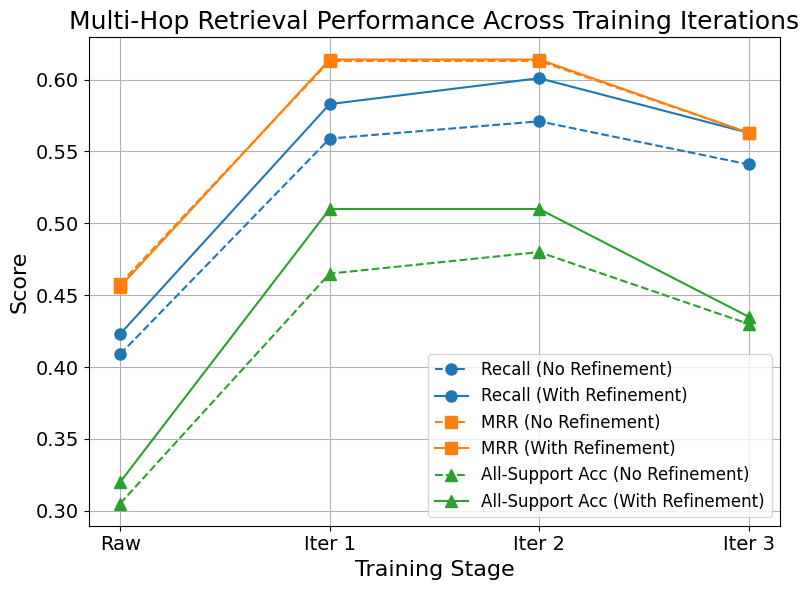

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the stages
stages = ['Raw', 'Iter 1', 'Iter 2', 'Iter 3']

# Define metrics
recall_no_refine = [0.409, 0.559, 0.571, 0.541]
recall_refine = [0.423, 0.583, 0.601, 0.563]

mrr_no_refine = [0.458, 0.613, 0.613, 0.563]
mrr_refine = [0.456, 0.614, 0.614, 0.563]

all_support_acc_no_refine = [0.305, 0.465, 0.480, 0.430]
all_support_acc_refine = [0.320, 0.510, 0.510, 0.435]

# Define colors
recall_color = 'tab:blue'
mrr_color = 'tab:orange'
all_support_color = 'tab:green'

# Set plot style
plt.figure(figsize=(8,6))

# Plot Recall
plt.plot(stages, recall_no_refine, marker='o', markersize=8, label='Recall (No Refinement)', linestyle='--', color=recall_color)
plt.plot(stages, recall_refine, marker='o', markersize=8, label='Recall (With Refinement)', linestyle='-', color=recall_color)

# Plot MRR
plt.plot(stages, mrr_no_refine, marker='s', markersize=8, label='MRR (No Refinement)', linestyle='--', color=mrr_color)
plt.plot(stages, mrr_refine, marker='s', markersize=8, label='MRR (With Refinement)', linestyle='-', color=mrr_color)

# Plot All-Support Accuracy
plt.plot(stages, all_support_acc_no_refine, marker='^', markersize=8, label='All-Support Acc (No Refinement)', linestyle='--', color=all_support_color)
plt.plot(stages, all_support_acc_refine, marker='^', markersize=8, label='All-Support Acc (With Refinement)', linestyle='-', color=all_support_color)

# Formatting
plt.xlabel('Training Stage', fontsize=16)
plt.ylabel('Score', fontsize=16)
plt.title('Multi-Hop Retrieval Performance Across Training Iterations', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)

# Legend with larger text
plt.legend(fontsize=12)

plt.tight_layout()

# Show plot
plt.show()
